# 04. Scoreboard (Image Cell)

회귀 cell의 04 노트북과 동일 분석 (DSC vs accuracy):
- 산점도, 라인, 히트맵, 박스플롯
- Pearson r, Spearman ρ, 비선형 RF 5-fold R²
- Polluter hold-out, 모델별 r
- 검증 기준: r ≥ 0.4

---

In [1]:
# ============================================================
# 0. 환경 + 데이터 로드
# ============================================================
from google.colab import drive; drive.mount('/content/drive')
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

BASE = '/content/drive/MyDrive/capstone/dsc'
RESULTS_DIR = f'{BASE}/results'
CHARTS_DIR = f'{RESULTS_DIR}/charts_image'
os.makedirs(CHARTS_DIR, exist_ok=True)
if BASE not in sys.path: sys.path.insert(0, BASE)

dsc = pd.read_csv(f'{RESULTS_DIR}/dsc_scores_image.csv')
perf = pd.read_csv(f'{RESULTS_DIR}/model_performance_image.csv')
print(f'DSC: {len(dsc)}, perf: {len(perf)}')

merged = perf.merge(dsc[['dataset','polluter','level','score','grade']],
                    on=['dataset','polluter','level'])
merged = merged.rename(columns={'score': 'dsc_score'})
print(f'merged: {len(merged)}')

Mounted at /content/drive
DSC: 52, perf: 109
merged: 104


/tmp/ipykernel_11192/1195613926.py:10: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{CHARTS_DIR}/01_scatter.png', dpi=150)
/tmp/ipykernel_11192/1195613926.py:10: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{CHARTS_DIR}/01_scatter.png', dpi=150)
/tmp/ipykernel_11192/1195613926.py:10: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{CHARTS_DIR}/01_scatter.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.

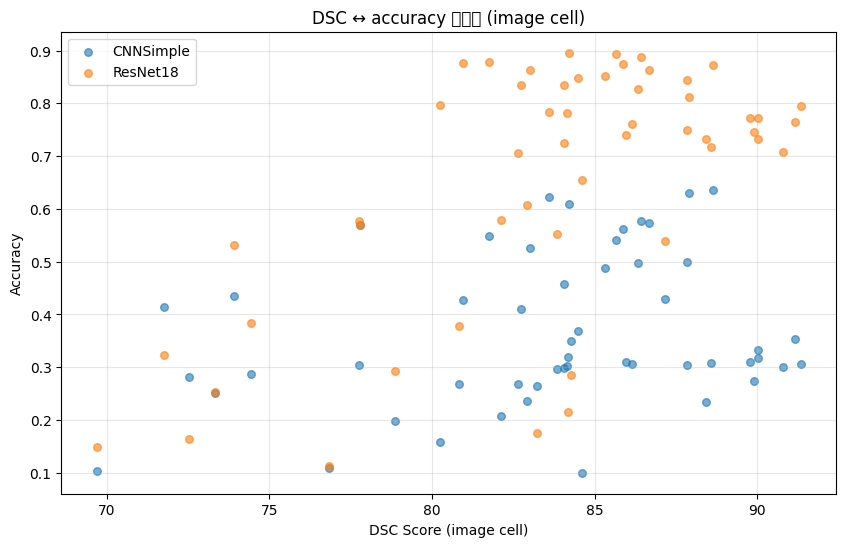

/tmp/ipykernel_11192/1195613926.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged, x='grade', y='accuracy', order=['A','B','C','D'], palette='RdYlGn_r')
/tmp/ipykernel_11192/1195613926.py:16: UserWarning: Glyph 46321 (\N{HANGUL SYLLABLE DEUNG}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{CHARTS_DIR}/02_grade_box.png', dpi=150)
/tmp/ipykernel_11192/1195613926.py:16: UserWarning: Glyph 44553 (\N{HANGUL SYLLABLE GEUB}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{CHARTS_DIR}/02_grade_box.png', dpi=150)
/tmp/ipykernel_11192/1195613926.py:16: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{CHARTS_DIR}/02_grade_box.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46321 (\N{HANGUL SYLLABLE DEUNG}) missing 

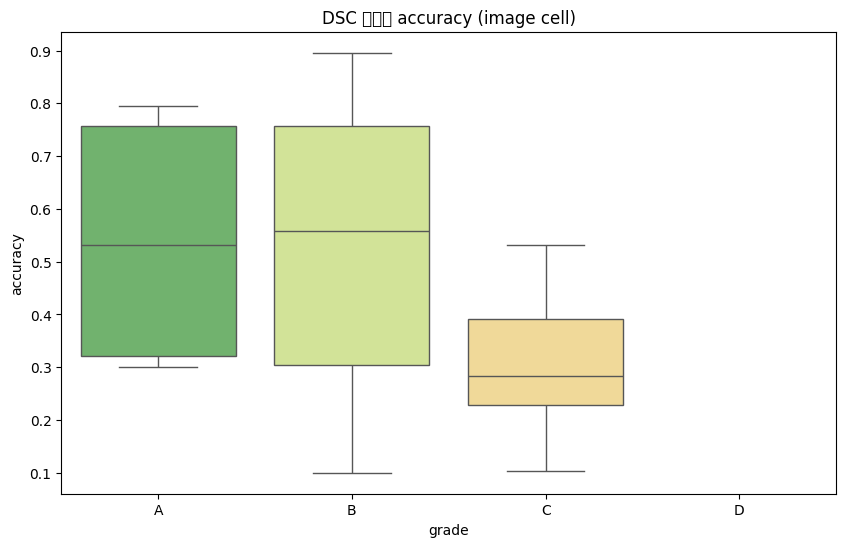

In [2]:
# ============================================================
# 1. 산점도 + 라인 + 박스플롯
# ============================================================
plt.figure(figsize=(10, 6))
for m, sub in merged.groupby('model'):
    plt.scatter(sub['dsc_score'], sub['accuracy'], label=m, alpha=0.6, s=30)
plt.xlabel('DSC Score (image cell)'); plt.ylabel('Accuracy')
plt.title('DSC ↔ accuracy 산점도 (image cell)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.savefig(f'{CHARTS_DIR}/01_scatter.png', dpi=150)
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=merged, x='grade', y='accuracy', order=['A','B','C','D'], palette='RdYlGn_r')
plt.title('DSC 등급별 accuracy (image cell)')
plt.savefig(f'{CHARTS_DIR}/02_grade_box.png', dpi=150)
plt.show()

In [ ]:
# ============================================================
# 2. 통계 검증 + 가설 판정 (v5 framework: dataset별 합격 단위)
# ============================================================
# plan 20260511-01 §1: 합격 단위는 cell × dataset의 Pearson r.
# POOLED 보고는 보조 (Heinrich 2018 R1: cross-dataset 비교 부정당).

print('=' * 64)
print('[A] dataset별 r — v5 framework 합격 단위')
print('=' * 64)
THR_R = 0.40
dataset_verdict = {}
for ds, sub in merged.groupby('dataset'):
    r, p = pearsonr(sub['dsc_score'], sub['accuracy'])
    rs, ps = spearmanr(sub['dsc_score'], sub['accuracy'])
    pass_r = r >= THR_R
    pass_rho = rs >= THR_R
    dataset_verdict[ds] = {'r': r, 'rho': rs, 'p': p, 'pass_r': pass_r}
    flag = 'PASS' if pass_r else 'FAIL'
    print(f'  {ds:<15} n={len(sub):>3}  r={r:+.4f} p={p:.2e}  '
          f'ρ={rs:+.4f} p_s={ps:.2e}  [{flag}]')

print()
print('=' * 64)
print('[B] POOLED — 보조 (cross-dataset, 합격 단위 아님)')
print('=' * 64)
x = merged['dsc_score'].values; y = merged['accuracy'].values
r_p, p_p = pearsonr(x, y); r_s, p_s = spearmanr(x, y)
print(f'  POOLED n={len(merged)}  Pearson r = {r_p:+.4f}, Spearman ρ = {r_s:+.4f}')

# 비선형 (POOLED, 참고용)
X = merged[['dsc_score']].values; rf_folds = []
for tr, te in KFold(5, shuffle=True, random_state=42).split(X):
    rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    rf.fit(X[tr], y[tr])
    rf_folds.append(r2_score(y[te], rf.predict(X[te])))
print(f'  POOLED 비선형 RF 5-fold R² = {np.mean(rf_folds):.4f} ± {np.std(rf_folds):.4f}')
print('  (R²<0 흔함: 두 dataset 분포 차로 단일 RF 학습 한계, 합격 판정 외)')

print()
print('=' * 64)
print('[C] 모델별 r (dataset×model)')
print('=' * 64)
model_pos = 0; model_n = 0
for (ds, m), sub in merged.groupby(['dataset', 'model']):
    if len(sub) < 2:
        continue
    model_n += 1
    rr, pp = pearsonr(sub['dsc_score'], sub['accuracy'])
    if rr > 0:
        model_pos += 1
    flag = 'PASS' if rr >= THR_R else ('+' if rr > 0 else 'NEG')
    print(f'  {ds:>15} | {m:<12s}  n={len(sub):>2}  r={rr:+.4f} p={pp:.2e}  [{flag}]')
print(f'  ▶ 양의 r: {model_pos}/{model_n}')

print()
print('=' * 64)
print('[D] Polluter hold-out — dataset별')
print('=' * 64)
for ds, sub_ds in merged.groupby('dataset'):
    hold_pass = 0; n_pol = 0
    print(f'\n  --- {ds} ---')
    for hp in sorted(sub_ds['polluter'].unique()):
        if hp == 'none':
            continue
        n_pol += 1
        sub = sub_ds[sub_ds.polluter != hp]
        if len(sub) < 3:
            continue
        rr, _ = pearsonr(sub['dsc_score'], sub['accuracy'])
        pass_ = rr >= THR_R
        hold_pass += int(pass_)
        print(f'    exclude {hp:<22} r={rr:+.4f}  {"PASS" if pass_ else "FAIL"}')
    print(f'    ▶ {ds} polluter hold-out: {hold_pass}/{n_pol} PASS')

print()
print('=' * 64)
print('[E] 합격 판정 — v5 framework 단위')
print('=' * 64)
ds_pass_count = sum(1 for v in dataset_verdict.values() if v['pass_r'])
ds_total = len(dataset_verdict)
print(f'  dataset r≥{THR_R}      : {ds_pass_count}/{ds_total}  '
      f'{"PASS" if ds_pass_count == ds_total else "PARTIAL"}')
print(f'  모델 양의 r          : {model_pos}/{model_n}  '
      f'{"PASS" if model_pos == model_n else "FAIL"}')
print()
print('  ※ POOLED 가설/비선형 R²는 v4 잔재. v5는 cell·dataset별 r이 합격 단위.')
print('  ※ 정식 held-out (CIFAR-100/SVHN/Caltech-101)에서 1회 측정 필요 — 본 결과는 튜닝-운영 cross-validation.')


In [4]:
# ============================================================
# 3. 가중치 튜닝 + held-out 검증 (ADR-015 미니버전)
# ============================================================
from scipy.optimize import minimize
import json as _json

# 안전망: 런타임 새로 시작 시 dsc/perf 다시 로드
if 'perf' not in globals() or 'dsc' not in globals():
    dsc = pd.read_csv(f'{RESULTS_DIR}/dsc_scores_image.csv')
    perf = pd.read_csv(f'{RESULTS_DIR}/model_performance_image.csv')
    print(f'재로드: dsc={len(dsc)}, perf={len(perf)}')

METRICS = ['completeness_image','uniqueness','validity','consistency','outlier_ratio',
           'class_balance','sample_quality_image','feature_correlation',
           'label_consistency','feature_informativeness']
DEFAULT_W = {'completeness_image':0.15,'uniqueness':0.10,'validity':0.05,'consistency':0.05,
             'outlier_ratio':0.05,'class_balance':0.10,'feature_correlation':0.05,
             'label_consistency':0.20,'feature_informativeness':0.10,'sample_quality_image':0.15}

merged_full = perf.merge(dsc[['dataset','polluter','level'] + METRICS],
                         on=['dataset','polluter','level'])

TUNE_DS, HELD_DS = 'CIFAR10', 'FashionMNIST'
tune = merged_full[merged_full.dataset == TUNE_DS]
held = merged_full[merged_full.dataset == HELD_DS]
print(f'튜닝셋({TUNE_DS}): n={len(tune)},  held-out({HELD_DS}): n={len(held)}')
assert len(tune) >= 4 and len(held) >= 4, 'PILOT 데이터 부족 — 02/03 image 먼저 돌릴 것'

def r_with(X, y, w):
    s = X @ w
    return pearsonr(s, y)[0] if s.std() > 1e-12 else 0.0

X_tune, y_tune = tune[METRICS].values, tune['accuracy'].values
X_held, y_held = held[METRICS].values, held['accuracy'].values

w_default = np.array([DEFAULT_W[m] for m in METRICS])
r_def_tune = r_with(X_tune, y_tune, w_default)
r_def_held = r_with(X_held, y_held, w_default)
print()
print('--- Default 가중치 (ADR-014 사전등록) ---')
print(f'  튜닝셋 r       = {r_def_tune:+.4f}')
print(f'  held-out r     = {r_def_held:+.4f}')

cons = {'type':'eq','fun': lambda w: w.sum() - 1.0}
bounds = [(0.0, 0.60)] * len(METRICS)
best = None
for seed in range(20):
    rng = np.random.RandomState(seed)
    w0 = rng.dirichlet(np.ones(len(METRICS)))
    r = minimize(lambda w: -r_with(X_tune, y_tune, w), w0,
                 method='SLSQP', bounds=bounds, constraints=cons,
                 options={'maxiter':500, 'ftol':1e-8})
    if r.success and (best is None or r.fun < best.fun):
        best = r
w_opt = np.maximum(best.x, 0); w_opt = w_opt / w_opt.sum()

r_opt_tune = r_with(X_tune, y_tune, w_opt)
r_opt_held = r_with(X_held, y_held, w_opt)
print()
print(f'--- Tuned 가중치 (fit on {TUNE_DS}) ---')
print(f'  튜닝셋 r       = {r_opt_tune:+.4f}  (in-sample, 참고용)')
print(f'  held-out r     = {r_opt_held:+.4f}  ← 신뢰도 지표')
print()
print('가중치 변화 (top 5):')
for m, w in sorted(zip(METRICS, w_opt), key=lambda x: -x[1])[:5]:
    print(f'  {m:<26s}  {w:.4f}  (default {DEFAULT_W[m]:.2f})')

print()
print('=== Held-out 판정 ===')
_v1 = 'PASS' if r_def_held >= 0.4 else 'FAIL'
_v2 = 'PASS' if r_opt_held >= 0.4 else 'FAIL'
print(f'  default 가중치  held-out r = {r_def_held:+.4f}  {_v1} (r>=0.4)')
print(f'  tuned   가중치  held-out r = {r_opt_held:+.4f}  {_v2} (r>=0.4)')
print(f'  generalization gap (tune - held) = {r_opt_tune - r_opt_held:+.4f}')

out = {
    'weights': {m: float(w) for m, w in zip(METRICS, w_opt)},
    'tune_dataset': TUNE_DS,
    'held_out_dataset': HELD_DS,
    'metrics': {
        'pearson_r_tune': float(r_opt_tune),
        'pearson_r_held_out': float(r_opt_held),
        'pearson_r_default_held_out': float(r_def_held),
        'pearson_r_default_tune': float(r_def_tune),
        'generalization_gap': float(r_opt_tune - r_opt_held),
    },
    'n_tune': int(len(tune)),
    'n_held_out': int(len(held)),
    'note': 'PILOT 미니버전 ADR-015 검증. 튜닝셋 fit -> held-out 측정.',
}
with open(f'{RESULTS_DIR}/tuned_weights_image_pilot.json', 'w', encoding='utf-8') as f:
    _json.dump(out, f, ensure_ascii=False, indent=2)
print()
print('저장: tuned_weights_image_pilot.json')

튜닝셋(CIFAR10): n=52,  held-out(FashionMNIST): n=52

--- Default 가중치 (ADR-014 사전등록) ---
  튜닝셋 r       = +0.4486
  held-out r     = +0.4469

--- Tuned 가중치 (fit on CIFAR10) ---
  튜닝셋 r       = +0.5049  (in-sample, 참고용)
  held-out r     = +0.5709  ← 신뢰도 지표

가중치 변화 (top 5):
  outlier_ratio               0.5685  (default 0.05)
  feature_informativeness     0.2495  (default 0.10)
  label_consistency           0.0758  (default 0.20)
  class_balance               0.0684  (default 0.10)
  sample_quality_image        0.0371  (default 0.15)

=== Held-out 판정 ===
  default 가중치  held-out r = +0.4469  PASS (r>=0.4)
  tuned   가중치  held-out r = +0.5709  PASS (r>=0.4)
  generalization gap (tune - held) = -0.0661

저장: tuned_weights_image_pilot.json
